영상 해상도: 640 x 480
첫 프레임 정자 수: 43개


C:\Users\neo62\AppData\Local\Temp\ipykernel_25496\1811610313.py:57: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_25496\1811610313.py:57: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_25496\1811610313.py:57: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_25496\1811610313.py:57: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_25496\1811610313.py:57: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_25496\1811610313.py:57: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from 

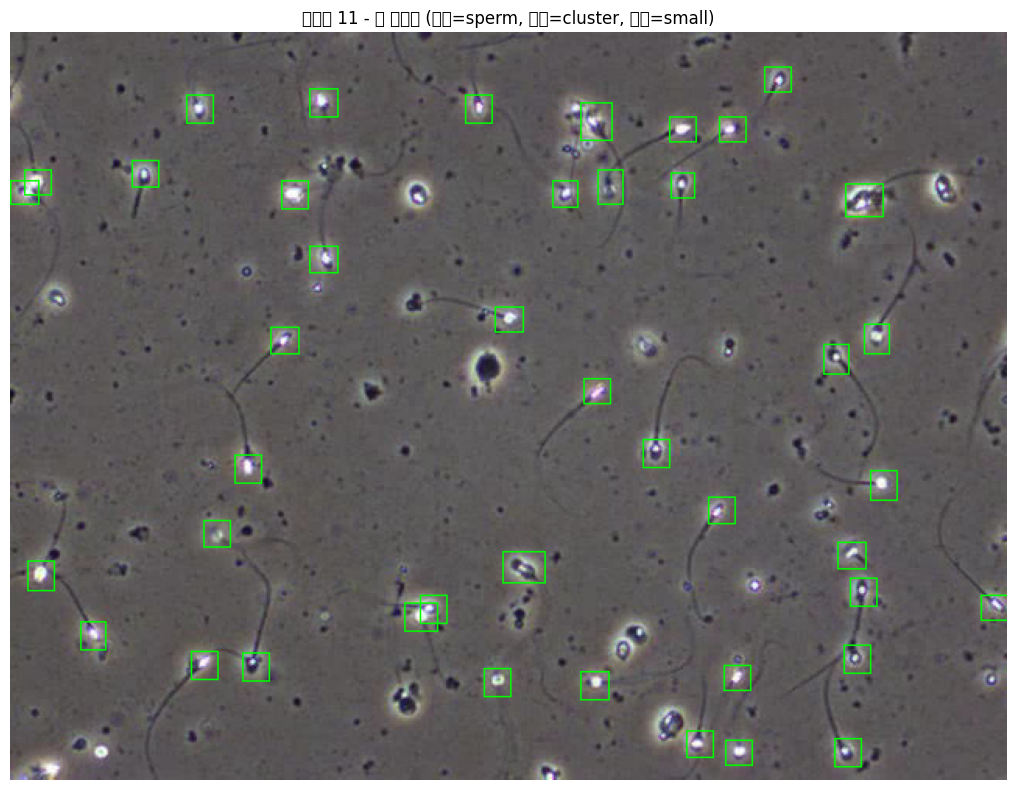

✅ 저장 완료: outputs/frame_visualization.png


In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# 경로 설정
base = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'
participant = '11'
p_path = os.path.join(base, participant)

video_path = os.path.join(p_path, f'{participant}.mp4')
labels_ftid_path = os.path.join(p_path, 'labels_ftid')

# 영상에서 첫 프레임 읽기
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

h, w = frame.shape[:2]
print(f"영상 해상도: {w} x {h}")

# 첫 프레임 라벨 읽기
ftid_files = sorted(os.listdir(labels_ftid_path))
label_file = os.path.join(labels_ftid_path, ftid_files[0])

with open(label_file, 'r') as f:
    lines = f.readlines()
print(f"첫 프레임 정자 수: {len(lines)}개")

# 바운딩 박스 그리기
colors = {0: (0, 255, 0), 1: (255, 0, 0), 2: (0, 0, 255)}
class_names = {0: 'sperm', 1: 'cluster', 2: 'small'}

vis_frame = frame.copy()
for line in lines:
    parts = line.strip().split()
    if len(parts) == 6:
        track_id, cls, cx, cy, bw, bh = parts[0], int(parts[1]), float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
    elif len(parts) == 5:
        cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        track_id = None

    # YOLO → 픽셀 좌표 변환
    x1 = int((cx - bw/2) * w)
    y1 = int((cy - bh/2) * h)
    x2 = int((cx + bw/2) * w)
    y2 = int((cy + bh/2) * h)

    color = colors.get(cls, (255, 255, 255))
    cv2.rectangle(vis_frame, (x1, y1), (x2, y2), color, 1)

# 결과 출력
plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
plt.title(f'참가자 {participant} - 첫 프레임 (초록=sperm, 파랑=cluster, 빨강=small)')
plt.axis('off')
plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\frame_visualization.png', dpi=150)
plt.show()
print("✅ 저장 완료: outputs/frame_visualization.png")

5프레임 이상 추적된 정자 수: 35개


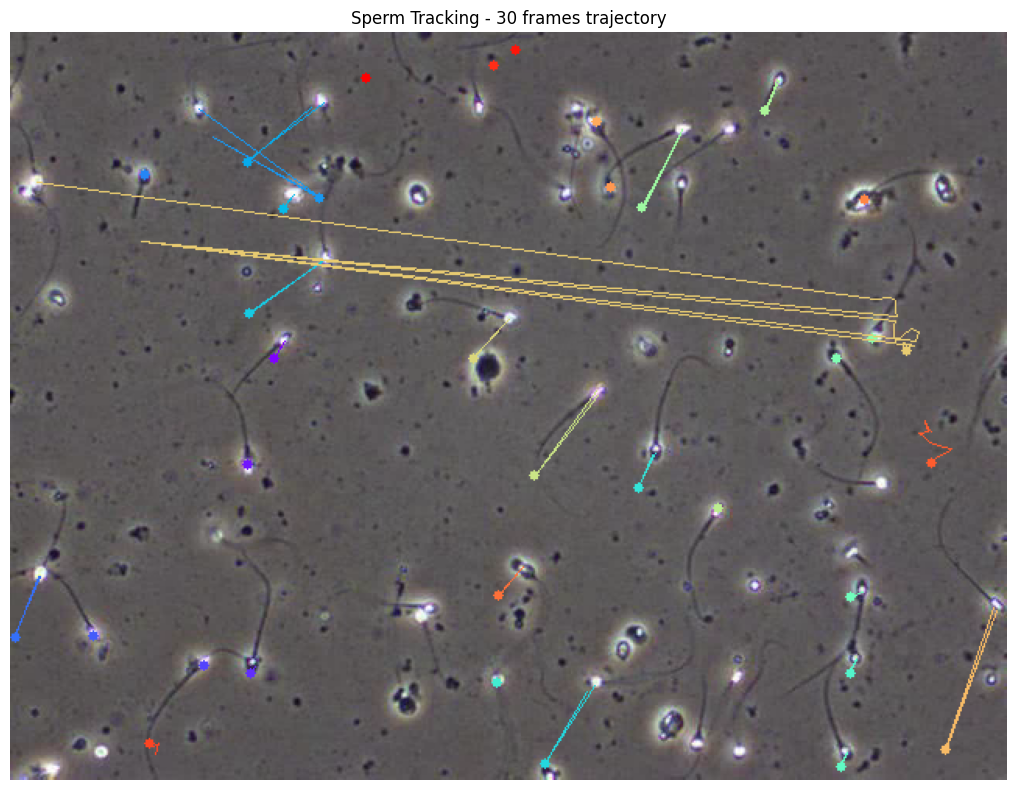

저장 완료: outputs/tracking_visualization.png


In [2]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

base = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'
participant = '11'
p_path = os.path.join(base, participant)
labels_ftid_path = os.path.join(p_path, 'labels_ftid')

# 첫 30프레임의 추적 데이터 읽기
ftid_files = sorted(os.listdir(labels_ftid_path))[:30]
tracks = defaultdict(list)  # {track_id: [(frame, cx, cy), ...]}

for frame_idx, fname in enumerate(ftid_files):
    fpath = os.path.join(labels_ftid_path, fname)
    with open(fpath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 6:
                tid, cls, cx, cy = parts[0], int(parts[1]), float(parts[2]), float(parts[3])
                if cls == 0:  # sperm만
                    tracks[tid].append((frame_idx, cx, cy))

# 영상 첫 프레임 불러오기
cap = cv2.VideoCapture(os.path.join(p_path, f'{participant}.mp4'))
ret, frame = cap.read()
cap.release()
h, w = frame.shape[:2]

# 경로 그리기 (5프레임 이상 추적된 것만)
vis = frame.copy()
long_tracks = {tid: pts for tid, pts in tracks.items() if len(pts) >= 5}
print(f"5프레임 이상 추적된 정자 수: {len(long_tracks)}개")

colors_list = plt.cm.rainbow(np.linspace(0, 1, len(long_tracks)))
for (tid, pts), color in zip(long_tracks.items(), colors_list):
    color_bgr = (int(color[2]*255), int(color[1]*255), int(color[0]*255))
    pixel_pts = [(int(cx*w), int(cy*h)) for _, cx, cy in pts]
    
    for i in range(1, len(pixel_pts)):
        cv2.line(vis, pixel_pts[i-1], pixel_pts[i], color_bgr, 1)
    cv2.circle(vis, pixel_pts[-1], 3, color_bgr, -1)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Sperm Tracking - 30 frames trajectory')
plt.axis('off')
plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\tracking_visualization.png', dpi=150)
plt.show()
print("저장 완료: outputs/tracking_visualization.png")

=== 데이터셋 기본 정보 ===
학습 이미지: (1000, 128, 128)  (1000개, 128×128, 그레이스케일)
픽셀 범위:   45 ~ 194

=== 레이블 분포 (0=정상, 1=비정상) ===
  머리(head)           정상: 727  비정상: 273  비정상 비율:27.3%
  첨체(acrosome)       정상: 699  비정상: 301  비정상 비율:30.1%
  공포(vacuole)        정상: 830  비정상: 170  비정상 비율:17.0%
  꼬리(tail)           정상: 954  비정상:  46  비정상 비율:4.6%

=== 샘플 이미지 시각화 ===


C:\Users\neo62\AppData\Local\Temp\ipykernel_2680\3789740037.py:46: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_2680\3789740037.py:46: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_2680\3789740037.py:46: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_2680\3789740037.py:46: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_2680\3789740037.py:46: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_2680\3789740037.py:46: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from fo

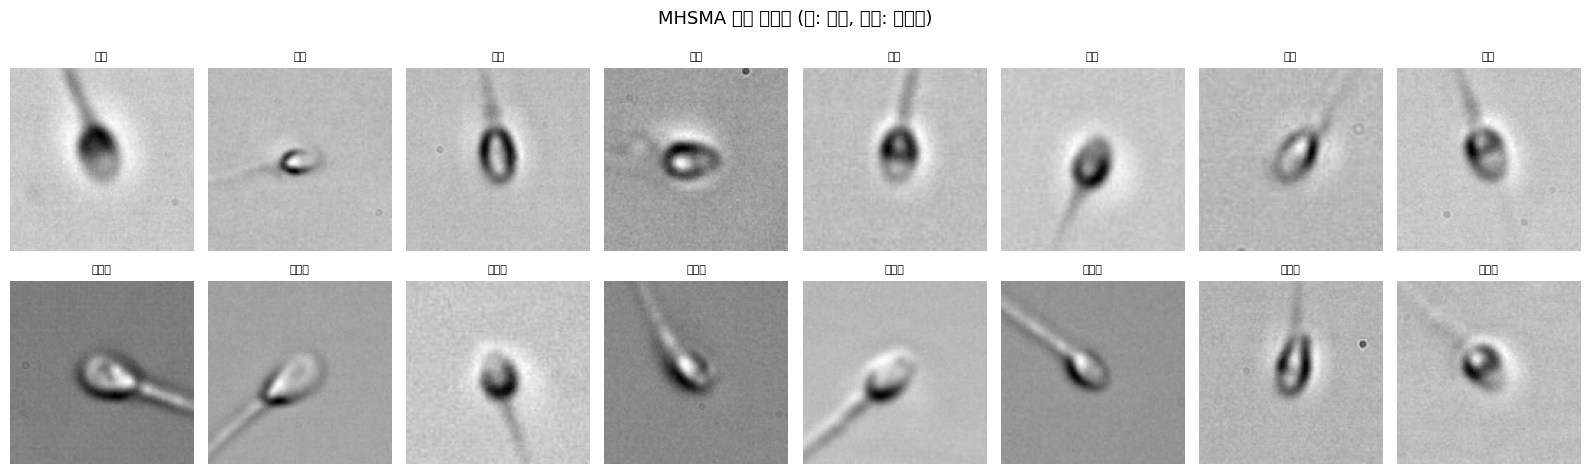

✅ 샘플 이미지 저장 완료


In [1]:
import numpy as np
import matplotlib.pyplot as plt

base = r'C:\Users\neo62\sperm-ai\data\raw\mhsma-dataset-master\mhsma-dataset-master\mhsma'

# 데이터 로드
x_train = np.load(f'{base}\\x_128_train.npy')
y_head     = np.load(f'{base}\\y_head_train.npy')
y_acrosome = np.load(f'{base}\\y_acrosome_train.npy')
y_vacuole  = np.load(f'{base}\\y_vacuole_train.npy')
y_tail     = np.load(f'{base}\\y_tail_train.npy')

print("=== 데이터셋 기본 정보 ===")
print(f"학습 이미지: {x_train.shape}  (1000개, 128×128, 그레이스케일)")
print(f"픽셀 범위:   {x_train.min()} ~ {x_train.max()}")

print("\n=== 레이블 분포 (0=정상, 1=비정상) ===")
for name, labels in [('머리(head)', y_head),
                      ('첨체(acrosome)', y_acrosome),
                      ('공포(vacuole)', y_vacuole),
                      ('꼬리(tail)', y_tail)]:
    n_normal   = int(np.sum(labels == 0))
    n_abnormal = int(np.sum(labels == 1))
    ratio = n_abnormal / len(labels) * 100
    print(f"  {name:<18} 정상:{n_normal:4d}  비정상:{n_abnormal:4d}  "
          f"비정상 비율:{ratio:.1f}%")

# 샘플 이미지 시각화
print("\n=== 샘플 이미지 시각화 ===")
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('MHSMA 샘플 이미지 (위: 정상, 아래: 비정상)', fontsize=13)

normal_idx   = np.where(y_head == 0)[0][:8]
abnormal_idx = np.where(y_head == 1)[0][:8]

for i, idx in enumerate(normal_idx):
    axes[0, i].imshow(x_train[idx], cmap='gray')
    axes[0, i].set_title(f'정상', fontsize=8)
    axes[0, i].axis('off')

for i, idx in enumerate(abnormal_idx):
    axes[1, i].imshow(x_train[idx], cmap='gray')
    axes[1, i].set_title(f'비정상', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\mhsma_samples.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("✅ 샘플 이미지 저장 완료")